#### 문제 전체 한글 포트 깨짐 [설치하기 or 영어로 바꾸기]

### 4.7

In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 24시간, 1초 단위
n = 86400
timestamps = pd.date_range("2025-08-15 00:00:00", periods=n, freq="1s")

# 정상 진동: 평균 0.28, 표준편차 0.05
vibration = np.random.normal(0.28, 0.05, n)

# 4시간 전(20:00 이후)부터 이상 신호 추가
anomaly_start = 20 * 3600  # 20시부터 (초 단위)
for i in range(anomaly_start, n):
    if np.random.random() < 0.05:  # 5% 확률로 튀는 값
        vibration[i] = np.random.uniform(0.5, 0.8)

# 온도와 부하는 정상 범위
temperature = np.random.normal(45, 3, n)
load = np.random.normal(200, 20, n)

df = pd.DataFrame(
    {
        "timestamp": timestamps,
        "vibration": vibration,
        "temperature": temperature,
        "load": load,
    }
)

df.to_csv("conveyor_data.csv", index=False)
print("데이터 생성 완료:", df.shape)
print(df.head())

데이터 생성 완료: (86400, 4)
            timestamp  vibration  temperature        load
0 2025-08-15 00:00:00   0.304836    48.118714  226.665369
1 2025-08-15 00:00:01   0.273087    44.375026  187.454525
2 2025-08-15 00:00:02   0.312384    48.287580  214.746737
3 2025-08-15 00:00:03   0.356151    45.203752  182.660890
4 2025-08-15 00:00:04   0.268292    40.686826  199.701327


In [2]:
import pandas as pd

# CSV 로드
df =pd.read_csv("conveyor_data.csv")

# 시간 컬럼을 datetime으로 변환
df["timestamp"] =pd.to_datetime(df["timestamp"])
# 시간을 인덱스로 설정
df =df.set_index("timestamp")

# 기본 정보 확인
print("데이터 크기:", df.shape)
print("\n각 컬럼 요약:")
print(df.describe())

print("\n처음 5행:")
print(df.head())

데이터 크기: (86400, 3)

각 컬럼 요약:
          vibration   temperature          load
count  86400.000000  86400.000000  86400.000000
mean       0.283303     45.010684    199.927896
std        0.061115      2.997494     19.981666
min        0.056720     32.757501    110.544384
25%        0.246648     43.000683    186.493124
50%        0.280765     45.003192    199.912427
75%        0.314931     47.012534    213.394450
max        0.798694     59.083418    292.334526

처음 5행:
                     vibration  temperature        load
timestamp                                              
2025-08-15 00:00:00   0.304836    48.118714  226.665369
2025-08-15 00:00:01   0.273087    44.375026  187.454525
2025-08-15 00:00:02   0.312384    48.287580  214.746737
2025-08-15 00:00:03   0.356151    45.203752  182.660890
2025-08-15 00:00:04   0.268292    40.686826  199.701327


### 4.8

In [ ]:
!pip install seaborn

Resolved 15 packages in 277ms
Installed 1 package in 51ms
 + seaborn==0.13.2


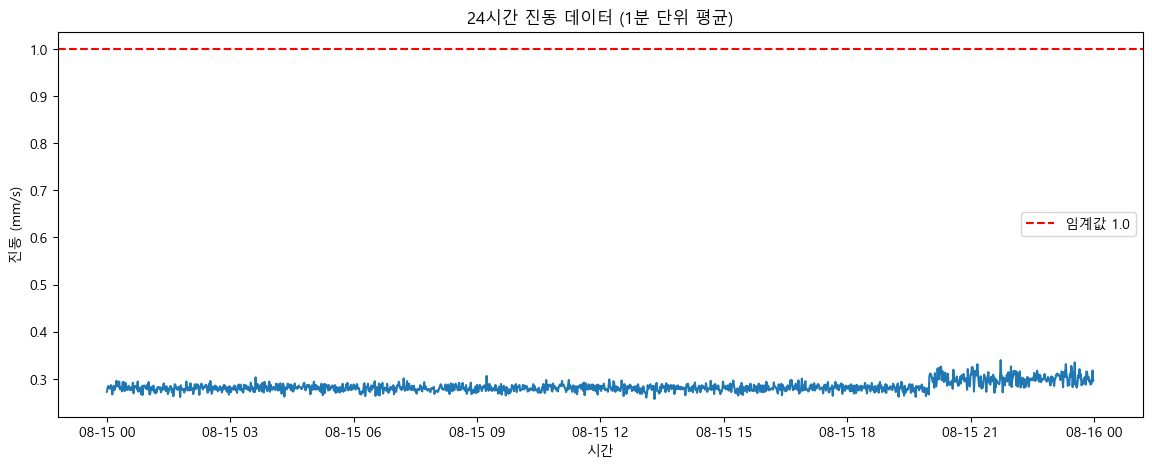

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 전체 데이터가 너무 많으므로 1분 단위로 리샘플링
df_1min =df.resample("1min").mean()

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_1min, x=df_1min.index, y="vibration")
plt.title("24시간 진동 데이터 (1분 단위 평균)")
plt.xlabel("시간")
plt.ylabel("진동 (mm/s)")
plt.axhline(y=1.0, color="red", linestyle="--", label="임계값 1.0")
plt.legend()
plt.show()

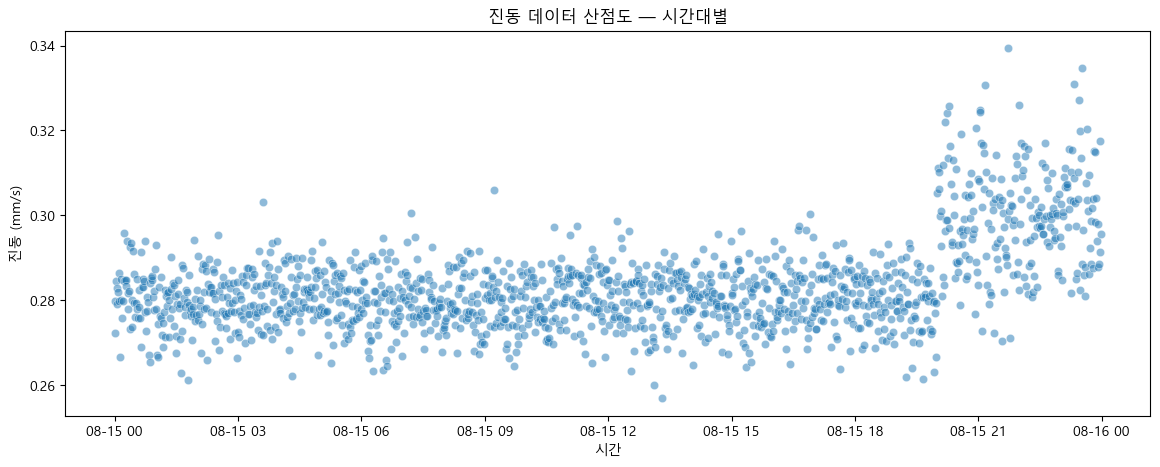

In [4]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(14, 5))
sns.scatterplot(data=df_1min, x=df_1min.index, y="vibration", alpha=0.5)
plt.title("진동 데이터 산점도 — 시간대별")
plt.xlabel("시간")
plt.ylabel("진동 (mm/s)")
plt.show()

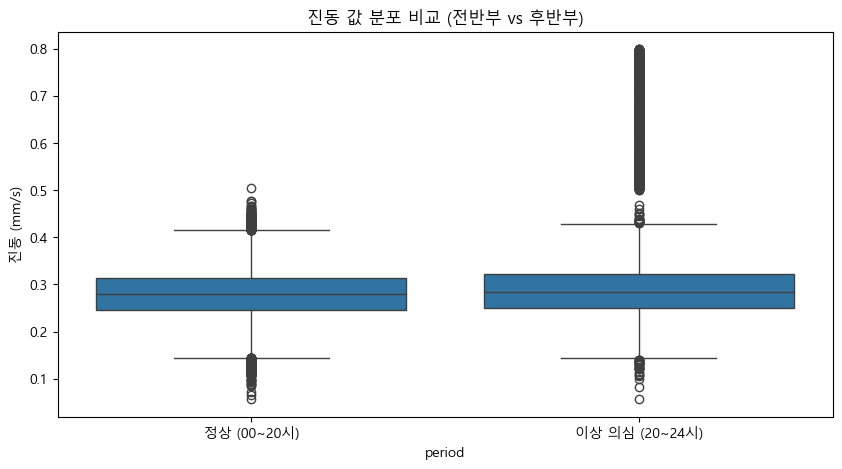

In [5]:
# 20시 이전과 이후로 분리
df["period"] =df.index.map(
    lambda x: "정상 (00~20시)"if x.hour <20 else "이상 의심 (20~24시)")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="period", y="vibration")
plt.title("진동 값 분포 비교 (전반부 vs 후반부)")
plt.ylabel("진동 (mm/s)")
plt.show()

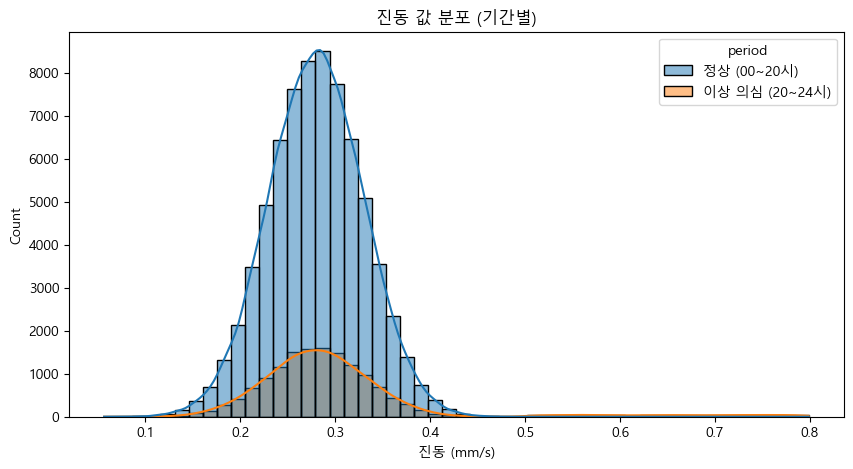

In [6]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="vibration", hue="period", kde=True, bins=50)
plt.title("진동 값 분포 (기간별)")
plt.xlabel("진동 (mm/s)")
plt.show()

### 4.9

In [8]:
import numpy as np


def detect_outliers_zscore(data, threshold=3):
    """Z-score 방법으로 이상치를 자동 탐지"""
    mean = data.mean()
    std = data.std()
    z_scores = (data - mean) / std
    outliers = data[np.abs(z_scores) > threshold]
    return outliers


# 진동 데이터에 적용
outliers_z = detect_outliers_zscore(df["vibration"])
print(f"Z-score 이상치 개수: {len(outliers_z)}")
print(f"이상치가 발생한 시간대:")
print(outliers_z.head(10))

Z-score 이상치 개수: 766
이상치가 발생한 시간대:
timestamp
2025-08-15 00:03:29    0.472637
2025-08-15 00:48:15    0.476312
2025-08-15 02:06:51    0.095582
2025-08-15 02:07:57    0.099946
2025-08-15 02:16:40    0.088167
2025-08-15 02:42:50    0.083880
2025-08-15 04:12:42    0.098240
2025-08-15 04:24:03    0.503954
2025-08-15 05:14:11    0.477117
2025-08-15 05:27:54    0.087181
Name: vibration, dtype: float64


In [9]:
def detect_outliers_iqr(data):
    """IQR 방법으로 이상치를 자동 탐지"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    return outliers


outliers_iqr = detect_outliers_iqr(df["vibration"])
print(f"IQR 이상치 개수: {len(outliers_iqr)}")

IQR 이상치 개수: 1275


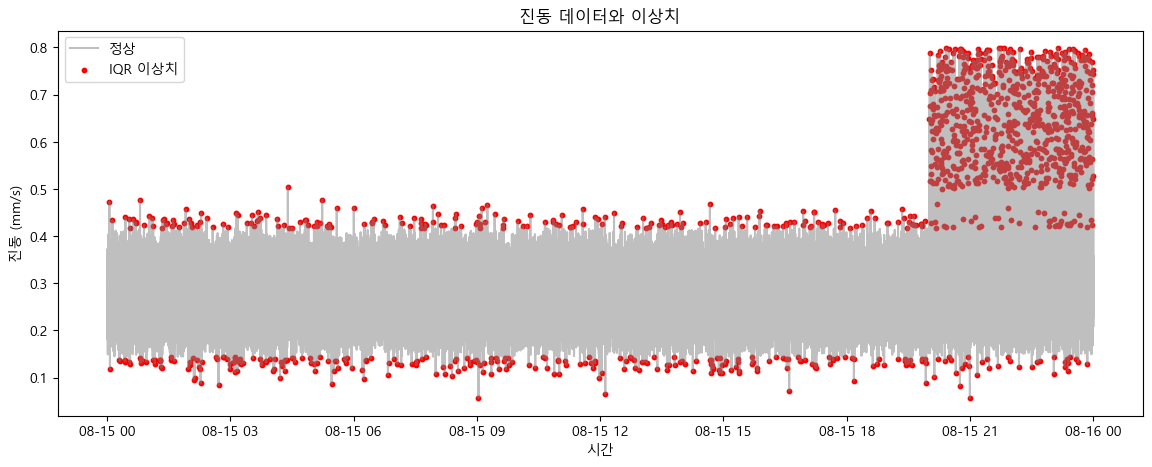

In [10]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
# 이상치가 발생한 시간을 시각적으로 표시
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["vibration"], color="gray", alpha=0.5, label="정상")
plt.scatter(outliers_iqr.index, outliers_iqr, color="red", s=10, label="IQR 이상치")
plt.title("진동 데이터와 이상치")
plt.xlabel("시간")
plt.ylabel("진동 (mm/s)")
plt.legend()
plt.show()

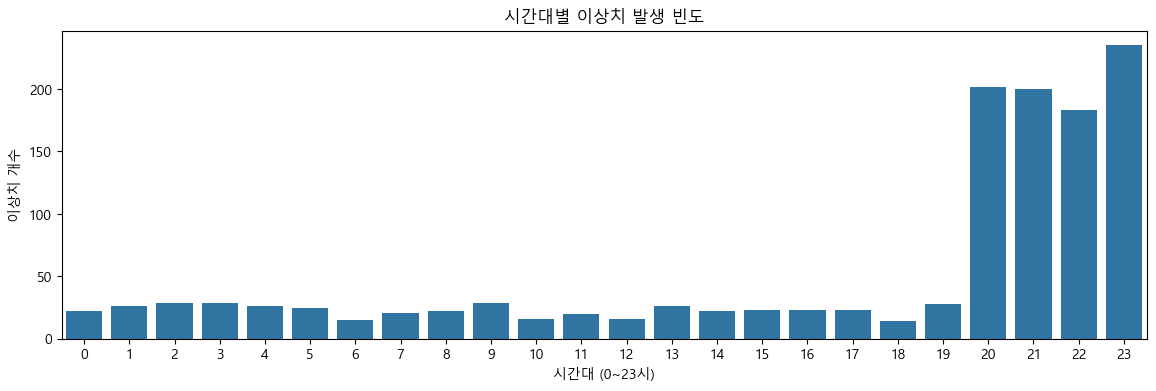

In [11]:
# 이상치를 1시간 단위로 카운트
outliers_iqr_df =pd.DataFrame({"outlier": True}, index=outliers_iqr.index)
hourly_count =outliers_iqr_df.resample("1h").sum()

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(14, 4))
sns.barplot(x=hourly_count.index.hour, y=hourly_count["outlier"])
plt.title("시간대별 이상치 발생 빈도")
plt.xlabel("시간대 (0~23시)")
plt.ylabel("이상치 개수")
plt.show()

In [30]:
def analyze_outliers(data, name="진동"):
    z_outliers =detect_outliers_zscore(data)
    iqr_outliers =detect_outliers_iqr(data)

    print(f"=== {name}이상치 분석 ===")
    print(f"전체 데이터 개수: {len(data):,}")
    print(f"Z-score 이상치: {len(z_outliers):,}개 "
        f"({len(z_outliers)/len(data)*100:.2f}%)")
    print(f"IQR 이상치: {len(iqr_outliers):,}개 "
        f"({len(iqr_outliers)/len(data)*100:.2f}%)")
    common =set(z_outliers.index) &set(iqr_outliers.index)
    print(f"공통 이상치: {len(common):,}개")
analyze_outliers(df["vibration"], "진동")

=== 진동이상치 분석 ===
전체 데이터 개수: 86,400
Z-score 이상치: 766개 (0.89%)
IQR 이상치: 1,275개 (1.48%)
공통 이상치: 766개
